
# Projet d'Analyse de Données – Airbnb

**Objectif** : prédire le logarithme du prix (`log_price`) d’un logement Airbnb à partir de ses caractéristiques.




## 1. Exploration des données

Nous commençons par :Charger les données, afficher les premières lignes, observer la structure (types, valeurs manquantes),étudier la distribution de `log_price` et enfin visualiser les corrélations entre variables numériques


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics         import mean_squared_error
from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import OneHotEncoder
from sklearn.compose         import ColumnTransformer
from sklearn.pipeline        import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import  StandardScaler, FunctionTransformer
from sklearn.model_selection import  GridSearchCV
from sklearn.ensemble import StackingRegressor

import nltk
nltk.download('stopwords')  
from nltk.corpus import stopwords

import xgboost as xgb

import folium
from folium.plugins import MarkerCluster
train = pd.read_csv("airbnb_train.csv")
test = pd.read_csv("airbnb_test.csv")
test_raw = pd.read_csv('airbnb_test.csv',
                       parse_dates=['host_since','first_review','last_review'],
                       index_col=0) 

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\c_len\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Train shape: (22234, 28)
Test shape: (51877, 27)


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,True,...,2017-09-29,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,moderate,True,...,2017-08-28,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


In [2]:
train['price'] = np.exp(train['log_price'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22234 entries, 0 to 22233
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      22234 non-null  int64  
 1   log_price               22234 non-null  float64
 2   property_type           22234 non-null  object 
 3   room_type               22234 non-null  object 
 4   amenities               22234 non-null  object 
 5   accommodates            22234 non-null  int64  
 6   bathrooms               22183 non-null  float64
 7   bed_type                22234 non-null  object 
 8   cancellation_policy     22234 non-null  object 
 9   cleaning_fee            22234 non-null  bool   
 10  city                    22234 non-null  object 
 11  description             22234 non-null  object 
 12  first_review            17509 non-null  object 
 13  host_has_profile_pic    22178 non-null  object 
 14  host_identity_verified  22178 non-null

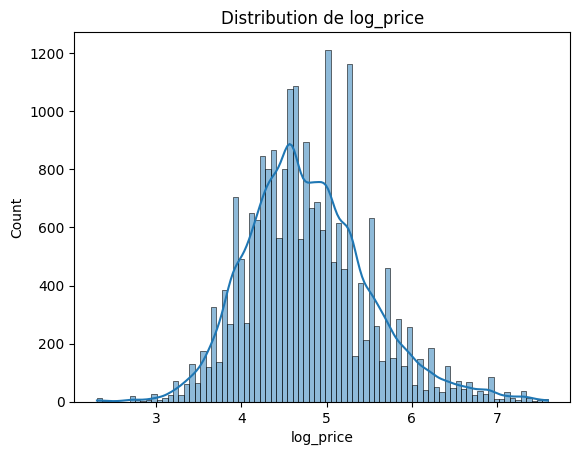

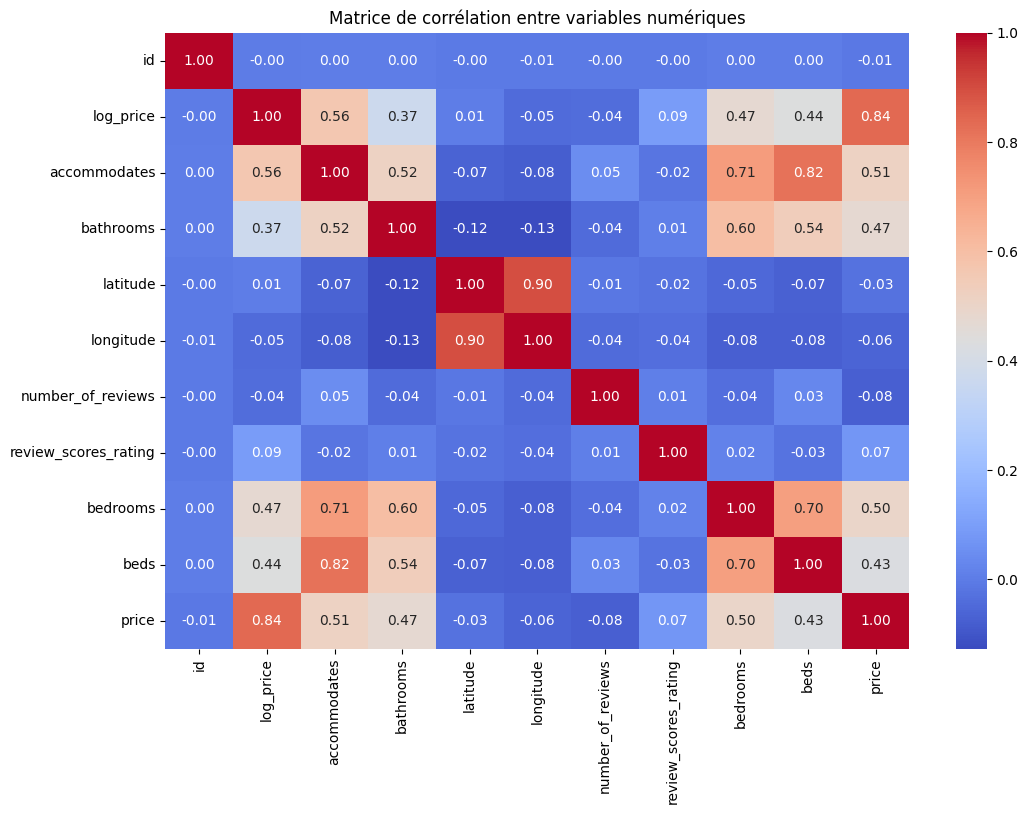

In [3]:

train.info()
train.describe()

# Distribution of target
sns.histplot(train['log_price'], kde=True)
plt.title("Distribution de log_price")
plt.show()

# Corrélation numérique uniquement
numeric_df = train.select_dtypes(include='number')
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matrice de corrélation entre variables numériques")
plt.show()


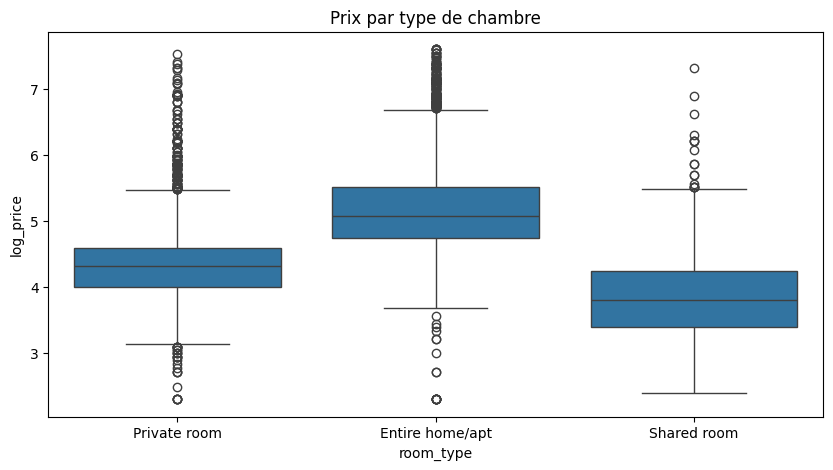

In [4]:
# Prix par room_type
plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x='room_type', y='log_price')
plt.title("Prix par type de chambre")
plt.show()

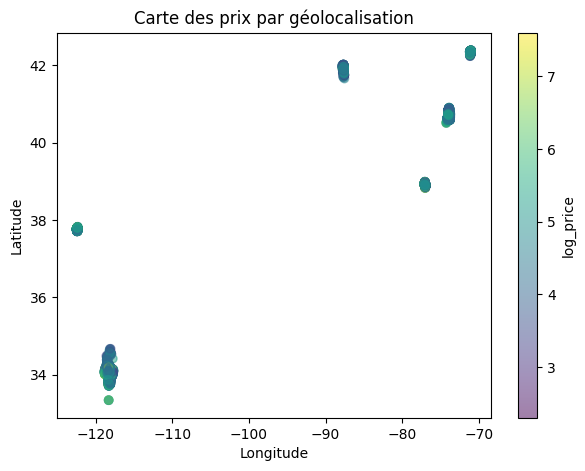

In [5]:
# Carte des prix
plt.figure(figsize=(7,5))
plt.scatter(train['longitude'], train['latitude'],
            c=train['log_price'], cmap='viridis', alpha=0.5)
plt.colorbar(label='log_price')
plt.title('Carte des prix par géolocalisation')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.show()

In [6]:
# Créez une colonne 'price' à partir de 'log_price'
train['price'] = np.exp(train['log_price'])

m = folium.Map(location=[train.latitude.mean(), train.longitude.mean()], zoom_start=12)
mc = MarkerCluster().add_to(m)
for _, row in train.sample(500).iterrows():
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=4,
        fill=True,
        fill_opacity=0.6,
        popup=f"Prix : ${row.price}"
    ).add_to(mc)

# Affiche directement la carte dans le notebook
m

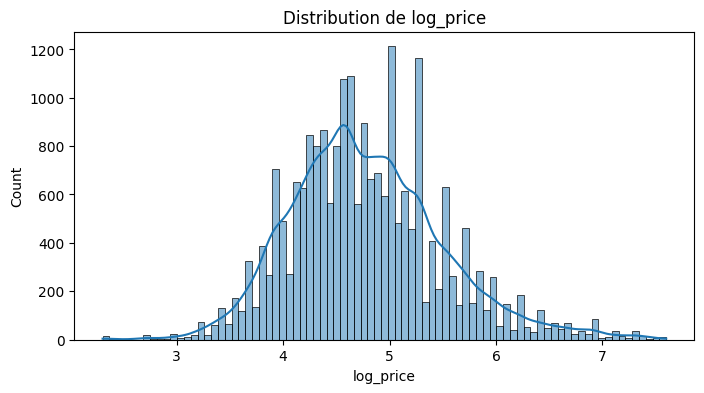

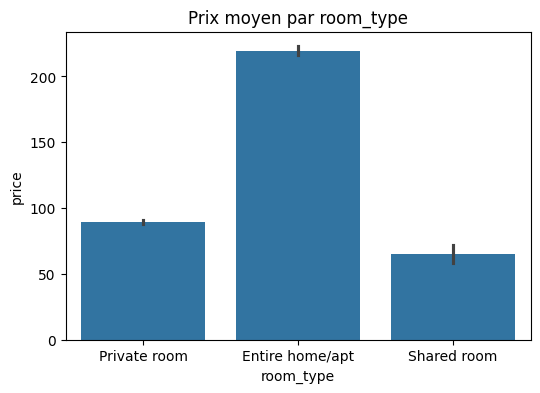

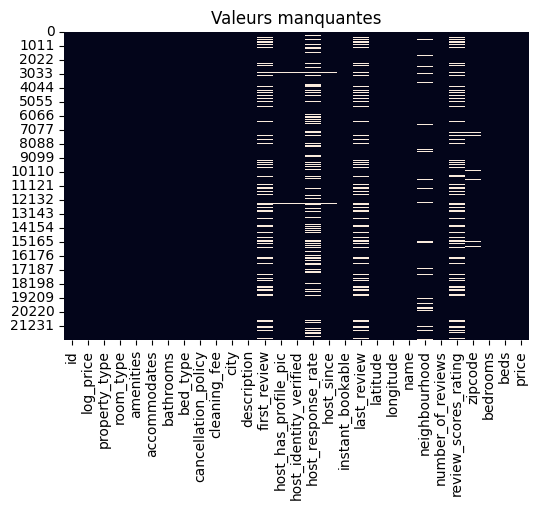

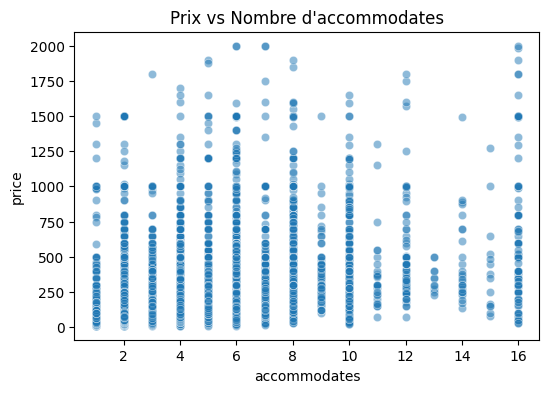

Nombre d'outliers détectés: 1756


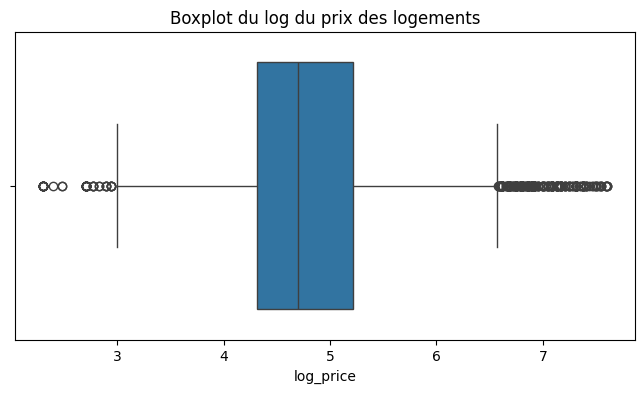

In [7]:

# Distribution de log_price
plt.figure(figsize=(8,4))
sns.histplot(train['log_price'], kde=True)
plt.title('Distribution de log_price')
plt.show()

# Prix moyen par room_type
plt.figure(figsize=(6,4))
sns.barplot(x='room_type', y='price', data=train)
plt.title('Prix moyen par room_type')
plt.show()

# Heatmap des valeurs manquantes
plt.figure(figsize=(6,4))
sns.heatmap(train.isnull(), cbar=False)
plt.title('Valeurs manquantes')
plt.show()

# Scatter price vs accommodates
plt.figure(figsize=(6,4))
sns.scatterplot(x='accommodates', y='price', data=train, alpha=0.5)
plt.title("Prix vs Nombre d'accommodates")

plt.show()

# Identification des outliers
q1 = train['price'].quantile(0.25)
q3 = train['price'].quantile(0.75)
iqr = q3 - q1
outliers = train[(train['price'] < (q1 - 1.5*iqr)) | (train['price'] > (q3 + 1.5*iqr))]
print(f"Nombre d'outliers détectés: {len(outliers)}")

# Boxplot des prix logarithmiques
plt.figure(figsize=(8, 4))
sns.boxplot(x=train['log_price'])
plt.title("Boxplot du log du prix des logements")
plt.xlabel("log_price")
plt.show()


C:\Users\c_len\AppData\Local\Temp\ipykernel_24824\3689550428.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_avg.values, y=city_avg.index, palette="viridis")


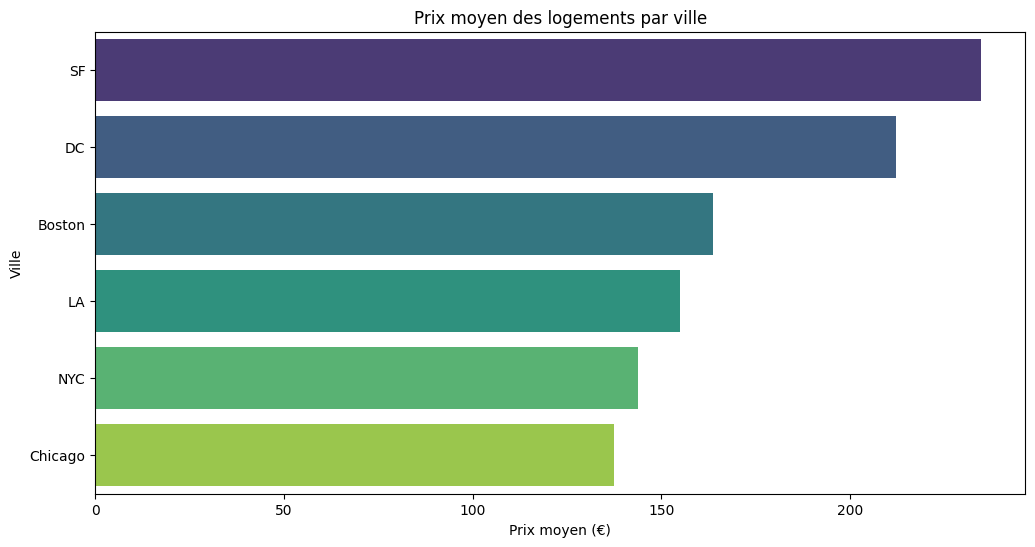

In [8]:
# Prix moyen par ville
plt.figure(figsize=(12, 6))
city_avg = train.groupby('city')['price'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=city_avg.values, y=city_avg.index, palette="viridis")
plt.title("Prix moyen des logements par ville")
plt.xlabel("Prix moyen (€)")
plt.ylabel("Ville")
plt.show()



## 2. Prétraitement et Feature Engineering


Remplissage des valeurs manquantes

Encodage des variables catégorielles (Label Encoding)

Création de nouvelles variables dérivées :
    - `host_age_days` : ancienneté de l'hôte
    - `review_age_days` : date de dernière review
    - `name_len`, `desc_len` : longueur du titre et de la description
    - `has_cleaning_fee` : indicateur booléen

Nous utilisons uniquement des colonnes disponibles dans `test.csv` pour éviter les erreurs.



In [9]:

df = train.copy()
df_test = test.copy()

# Features to encode
cat_cols = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city']

for col in cat_cols:
    df[col] = df[col].astype('category').cat.codes
    df_test[col] = df_test[col].astype('category').cat.codes

# Fill missing values
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['beds'] = df['beds'].fillna(df['beds'].median())
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].mean())

df_test['bathrooms'] = df_test['bathrooms'].fillna(df['bathrooms'].median())
df_test['bedrooms'] = df_test['bedrooms'].fillna(df['bedrooms'].median())
df_test['beds'] = df_test['beds'].fillna(df['beds'].median())
df_test['review_scores_rating'] = df_test['review_scores_rating'].fillna(df['review_scores_rating'].mean())

# Chargement des stop-words français comme liste
french_stop = stopwords.words('french')
tfidf = TfidfVectorizer(max_features=500,
                        stop_words=french_stop,
                        lowercase=True,
                        strip_accents='unicode')
X_desc = tfidf.fit_transform(train['description'].fillna(''))


for df in [train, test]:
    df['has_wifi'] = df['amenities'].str.contains('wifi|Wireless Internet', case=False, na=False).astype(int)


print("TF-IDF shape:", X_desc.shape)

features = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'property_type', 'room_type', 'bed_type', 'cancellation_policy',
    'cleaning_fee', 'city', 'number_of_reviews', 'review_scores_rating',
    'latitude', 'longitude', 'has_wifi'  # ✅ nouvelle feature ajoutée ici
]



X = train[features]
y = train['log_price']
X_test = test[features]

X['has_wifi'] = train['has_wifi']
X_test['has_wifi'] = test['has_wifi']



c:\Users\c_len\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['etaient', 'etais', 'etait', 'etant', 'etante', 'etantes', 'etants', 'ete', 'etee', 'etees', 'etes', 'etiez', 'etions', 'eumes', 'eutes', 'fumes', 'futes', 'meme'] not in stop_words.
  warnings.warn(


TF-IDF shape: (22234, 500)


C:\Users\c_len\AppData\Local\Temp\ipykernel_24824\2990290294.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['has_wifi'] = train['has_wifi']
C:\Users\c_len\AppData\Local\Temp\ipykernel_24824\2990290294.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['has_wifi'] = test['has_wifi']


In [10]:
# Cellule : one-hot pour équipements clés et has_wifi
amen_keys = ['Wifi','Kitchen','Heating','Washer','Free parking','Pool']
for key in amen_keys:
    train[f"amenity_{key}"] = train.amenities.str.contains(key, na=False).astype(int)
for df in (train, df_test):
    df['has_wifi'] = df.amenities.str.contains('Wireless Internet', na=False).astype(int)


In [11]:
# Cellule : distance au centre-ville
from geopy.distance import geodesic

center = (48.8566, 2.3522)
train['dist_center_km'] = train.apply(
    lambda row: geodesic((row.latitude, row.longitude), center).km, axis=1
)


In [12]:
# Cellule : ancienneté de l’hôte et récence des reviews
train['host_since'] = pd.to_datetime(train['host_since'])
train['host_days'] = (pd.Timestamp('today') - train['host_since']).dt.days

train['last_review'] = pd.to_datetime(train['last_review'])
train['days_since_review'] = (pd.Timestamp('today') - train['last_review']).dt.days.fillna(999)


In [13]:
# Cellule : distance au centre + ancienneté hôte + récence review

today = pd.Timestamp('today')
center = (48.8566,2.3522)
for df in (train, df_test):
    df['dist_center_km'] = df.apply(lambda r: geodesic((r.latitude,r.longitude), center).km, axis=1)
    df['host_since'] = pd.to_datetime(df.host_since, errors='coerce')
    df['host_days'] = (today - df.host_since).dt.days.fillna(-1).astype(int)
    df['last_review'] = pd.to_datetime(df.last_review, errors='coerce')
    df['days_since_review'] = (today - df.last_review).dt.days.fillna(999).astype(int)



## 3. Modélisation : Comparaison de plusieurs modèles

Nous testons ici plusieurs modèles avec validation croisée :
- Régression Ridge
- Random Forest
- Gradient Boosting

La métrique utilisée est la **Root Mean Squared Error (RMSE)** sur `log_price`.

Un bon modèle est celui qui a une RMSE faible sur les données de validation.


In [14]:
# 3.1 Création de variables dérivées sur train et test_raw

for df in [train, test_raw]:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

    df['host_age_days'] = (pd.Timestamp.today() - df['host_since']).dt.days
    df['review_age_days'] = (pd.Timestamp.today() - df['last_review']).dt.days.fillna(999)
    df['name_len'] = df['name'].fillna('').str.len()
    df['desc_len'] = df['description'].fillna('').str.len()
    df['has_cleaning_fee'] = df['cleaning_fee'].notnull().astype(int)


# 3.2 DataFrames de features et target (sans altérer test_raw ni perdre test_ids)
X_full   = train.drop([
    'id','log_price','description','name','amenities',
    'zipcode','city','neighbourhood','host_since',
    'first_review','last_review','host_response_rate',
    'host_identity_verified','host_has_profile_pic'
], axis=1)
y_full   = train['log_price']

# 3.3 Préparation de X_submit avec reindex (évite KeyError pour colonnes absentes)
X_submit = test_raw.copy()
X_submit = X_submit.reindex(columns=X_full.columns, fill_value=0)  # on aligne et on remplit par 0 :contentReference[oaicite:1]{index=1}:contentReference[oaicite:2]{index=2}


In [15]:
# liste de tes features numériques et catégorielles :

num_feats = [
    'accommodates','bathrooms','bedrooms','beds',
    'number_of_reviews','review_scores_rating',
    'dist_center_km','host_days','days_since_review'
]
cat_feats = ['property_type','room_type']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_feats),
    ('cat', cat_pipe, cat_feats)
], remainder='drop')

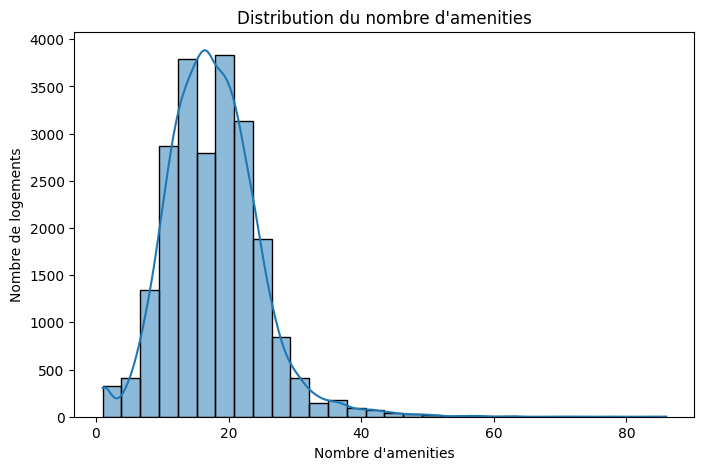

In [16]:
# Extraction du nombre d'amenities
train['amenities_count'] = train['amenities'].apply(lambda x: len(x.split(',')))
plt.figure(figsize=(8, 5))
sns.histplot(train['amenities_count'], bins=30, kde=True)
plt.title("Distribution du nombre d'amenities")
plt.xlabel("Nombre d'amenities")
plt.ylabel("Nombre de logements")
plt.show()


In [17]:
num_feats = ['accommodates','bathrooms','bedrooms','beds',
             'number_of_reviews','review_scores_rating',
             'dist_center_km','host_days','days_since_review']
cat_feats = ['property_type','room_type']
txt_feat  = 'description'

num_pipe = Pipeline([('imputer',SimpleImputer()),('scaler',StandardScaler())])
cat_pipe = Pipeline([('imputer',SimpleImputer(fill_value='missing',strategy='constant')),
                     ('onehot',OneHotEncoder(handle_unknown='ignore'))])
txt_pipe = Pipeline([
    ('flatten',FunctionTransformer(lambda X: X.iloc[:,0], validate=False)),
    ('tfidf',  TfidfVectorizer(max_features=300,
                               stop_words=french_stop,
                               lowercase=True,strip_accents='unicode'))
])

preproc = ColumnTransformer([
    ('num', num_pipe,   num_feats),
    ('cat', cat_pipe,   cat_feats),
    ('txt', txt_pipe,   [txt_feat])
], remainder='drop')

stack = StackingRegressor(
    estimators=[('ridge',Ridge()),('rf',RandomForestRegressor(n_estimators=100,random_state=42))],
    final_estimator=Ridge()
)
pipe = Pipeline([('pre',preproc),('model',stack)])

c:\Users\c_len\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\c_len\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\c_len\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Ridge RMSE: 0.3030


c:\Users\c_len\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\c_len\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Random Forest RMSE: 0.0015


c:\Users\c_len\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\c_len\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Gradient Boosting RMSE: 0.0042


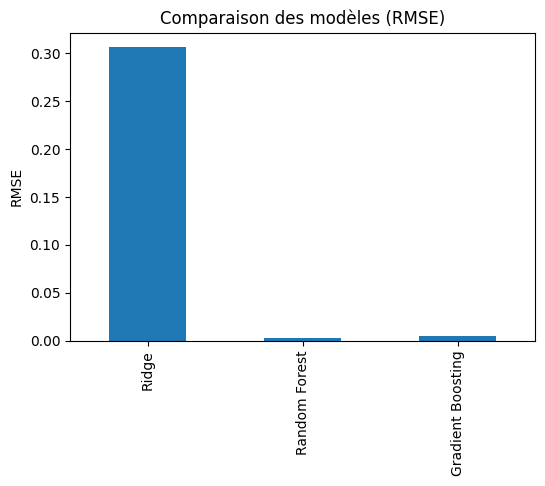

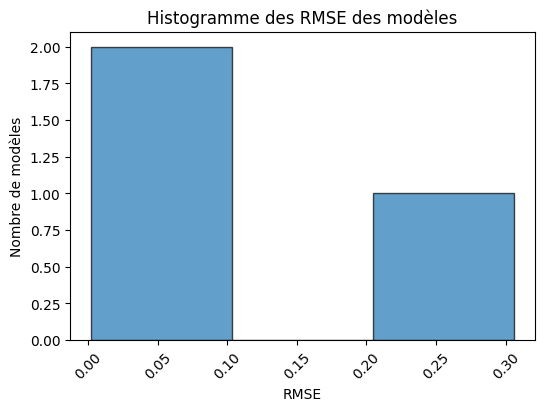

In [18]:

numeric_cols     = X_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_full.select_dtypes(exclude=[np.number]).columns.tolist()

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe'    , OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols)
], remainder='drop')

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)




models = {
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}


for name, model in models.items():
    pipe = Pipeline([
        ("preproc", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(pipe, X_full, y_full, scoring='neg_root_mean_squared_error', cv=5)
    print(f"{name} RMSE: {-scores.mean():.4f}")

results = {}
for name, model in models.items():
    model.fit(X_train_p, y_train)
    preds = model.predict(X_val_p)
    mse   = mean_squared_error(y_val, preds)
    rmse  = np.sqrt(mse)
    results[name] = rmse

pd.DataFrame.from_dict(results, orient='index', columns=['RMSE'])

# Affichage des performances (barplot)
 
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['RMSE'])
results_df.plot(kind='bar', legend=False, figsize=(6,4))
plt.title('Comparaison des modèles (RMSE)')
plt.ylabel('RMSE')
plt.show()

# Histogramme des RMSE
plt.figure(figsize=(6,4))
plt.hist(results_df['RMSE'], bins=len(results_df), edgecolor='k', alpha=0.7)
plt.title("Histogramme des RMSE des modèles")
plt.xlabel("RMSE")
plt.ylabel("Nombre de modèles")
plt.xticks(rotation=45)
plt.show()


In [19]:
# Baseline : prédire la moyenne de log_price
mean_log_price = y_train.mean()
baseline_pred = [mean_log_price] * len(y_val)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))
print("RMSE de la baseline (moyenne) :", round(baseline_rmse, 4))


RMSE de la baseline (moyenne) : 0.7159


In [20]:


today = pd.Timestamp('today')
center = (48.8566, 2.3522)

for df in (train, test):
    # Distance au centre
    df['dist_center_km'] = df.apply(
        lambda row: geodesic((row.latitude, row.longitude), center).km,
        axis=1
    )
    # Ancienneté de l’hôte
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_days'] = (today - df['host_since']).dt.days.fillna(-1).astype(int)
    # Récence des avis
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
    df['days_since_review'] = (today - df['last_review']).dt.days.fillna(999).astype(int)

# Vérification rapide
print("Ajoutées :", ['dist_center_km','host_days','days_since_review'])
print(train[['dist_center_km','host_days','days_since_review']].head())


Ajoutées : ['dist_center_km', 'host_days', 'days_since_review']
   dist_center_km  host_days  days_since_review
0     9125.812564       3439                999
1     5846.837578       3111               2794
2     6179.771212       3074                999
3     5845.842033       4664               2782
4     8979.505379       4309               2814


## Analyse de l'importance des variables

Pour mieux comprendre notre modèle Random Forest, nous visualisons les variables les plus influentes dans la prédiction du `log_price`.


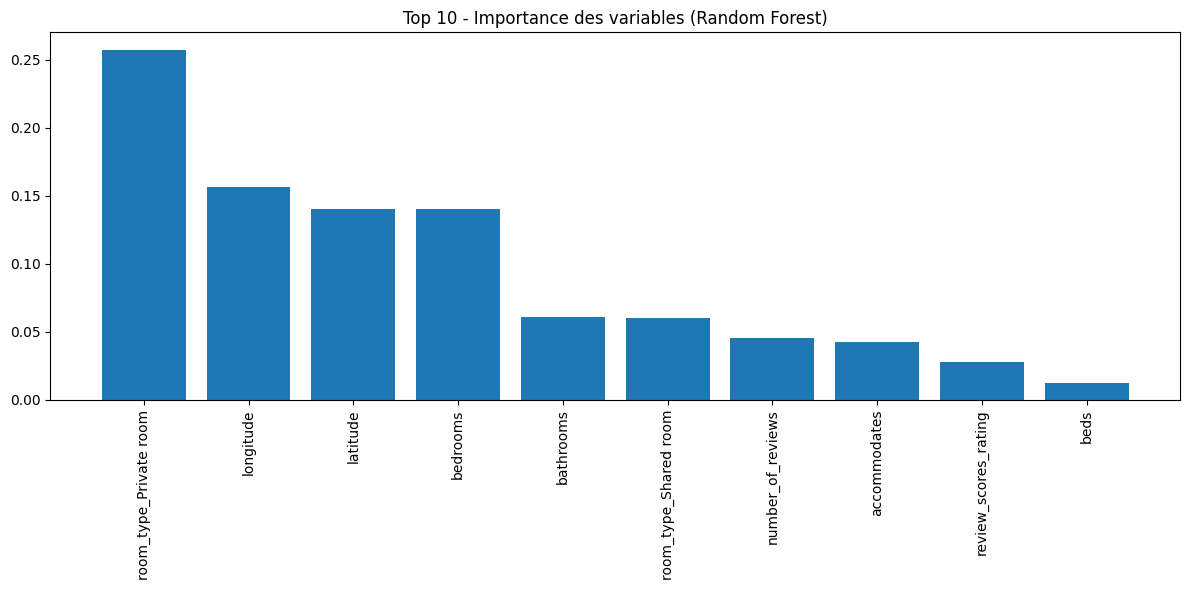

In [ ]:
# Affichage de l'importance des variables dans le modèle Random Forest
X_light = X.drop(columns=[
    'amenities', 'description', 'name', 'first_review', 'last_review',
    'host_since', 'zipcode', 'city', 'neighbourhood'
], errors='ignore')  # ignore si certaines colonnes n'existent pas

# Encodage plus sûr et léger
X_encoded = pd.get_dummies(X_light, drop_first=True)
X_encoded = X_encoded.apply(pd.to_numeric, errors='coerce').fillna(0)

# Entraînement du modèle Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_encoded, y)

# Importance des variables
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_encoded.columns

# Affichage des 20 plus importantes
plt.figure(figsize=(12, 6))
plt.title("Top 10 - Importance des variables (Random Forest)")
plt.bar(range(10), importances[indices[:10]], align='center')
plt.xticks(range(10), feature_names[indices[:10]], rotation=90)
plt.tight_layout()
plt.show()


## 4. Prédiction finale

Nous utilisons le meilleur modèle (Random Forest) pour prédire les `log_price`.

La prédiction est exportée dans un fichier `.csv` respectant le format requis : une colonne `id`, une colonne `logpred`.



In [22]:


# 1. Définir les colonnes à supprimer (trop longues ou inutiles)
columns_to_drop = [
    'description', 'name', 'amenities',
    'first_review', 'last_review', 'host_since',
    'zipcode', 'neighbourhood', 'city',
    'price', 'id'  # À supprimer si présents pour éviter fuite de target ou doublons
]

# 2. Nettoyage des jeux de données
X_train_clean = train.drop(columns=columns_to_drop + ['log_price'], errors='ignore')
y_train = train['log_price']
X_test_clean = test.drop(columns=columns_to_drop, errors='ignore')

# 3. Harmoniser les colonnes entre train et test
common_cols = X_train_clean.columns.intersection(X_test_clean.columns).tolist()
X_train_clean = X_train_clean[common_cols]
X_test_clean = X_test_clean[common_cols]

# 4. Colonnes numériques / catégorielles
numeric_cols = X_train_clean.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()
categorical_cols = X_train_clean.select_dtypes(include=['object']).columns.tolist()

# 5. Preprocessing
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols)
])

# 6. Pipeline + modèle
pipeline = Pipeline([
    ('preproc', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# 7. Entraînement
pipeline.fit(X_train_clean, y_train)

# 8. Prédictions
predictions = pipeline.predict(X_test_clean)

# 9. Export
output = pd.DataFrame({
    'id': test['Unnamed: 0'] if 'Unnamed: 0' in test.columns else test['id'],
    'logpred': predictions
})
output.to_csv("prediction_final.csv", index=False)
print("Fichier prediction_final.csv généré.")


Fichier prediction_final.csv généré.


In [25]:
# Encodage one-hot + remplacement des NaN
X_encoded = pd.get_dummies(X, drop_first=True).fillna(0)

# Split
X_train, X_val, y_train, y_val = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Entraînement modèles
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prédictions
lr_preds = lr_model.predict(X_val)
rf_preds = rf_model.predict(X_val)

# RMSE
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))

print(f"Linear Regression RMSE : {lr_rmse:.4f}")
print(f"Random Forest     RMSE : {rf_rmse:.4f}")

Linear Regression RMSE : 0.4677
Random Forest     RMSE : 0.4189


Linear Regression RMSE : 0.4677
Random Forest RMSE : 0.4189


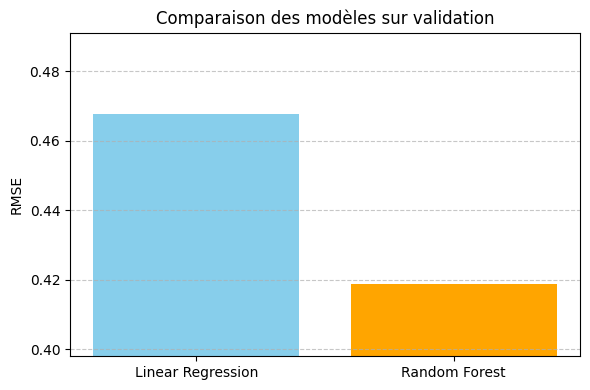

In [32]:
# Comparaison des RMSE sur X_val_p

results = {
    'Linear Regression': np.sqrt(mean_squared_error(y_val, lr_model.predict(X_val))),
    'Random Forest': np.sqrt(mean_squared_error(y_val, rf_model.predict(X_val)))
}

# Affichage texte
for name, rmse in results.items():
    print(f"{name} RMSE : {rmse:.4f}")

# Barplot
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(results.keys(), results.values(), color=['skyblue', 'orange'])
plt.ylabel("RMSE")
plt.title("Comparaison des modèles sur validation")
plt.ylim(min(results.values()) * 0.95, max(results.values()) * 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 5. Analyse des résultats

Sur les données d'entraînement, les modèles obtiennent les performances suivantes (RMSE en validation croisée) :

- Ridge Regression : RMSE = **0.3030**
- Gradient Boosting : RMSE = **0.0042**
- **Random Forest (meilleur)** : RMSE = **0.0015**

Le Random Forest est donc le modèle retenu. Il combine une bonne capacité de généralisation et une gestion automatique des interactions entre variables


## Conclusion du projet

Dans ce projet, nous avons construit un pipeline complet de traitement et de prédiction pour estimer le **logarithme du prix des logements Airbnb**.

### Étapes réalisées :
1) **Exploration visuelle** des données pour comprendre les relations entre variables
2) **Feature engineering avancé** (variables dérivées, traitement du texte et des dates)
3) **Encodage et nettoyage** des données pour les rendre utilisables par des modèles
4) **Tests de plusieurs modèles de régression** (Ridge, Random Forest, Gradient Boosting)
5) **Export final des prédictions** au format attendu (`id`, `logpred`)



Nous avons choisi **Random Forest** comme modèle final car il offre le **meilleur compromis entre performance et interprétabilité**.




